# Análise Preditiva de RH - TechNova Solutions
## Análise Exploratória de Dados (EDA) + Machine Learning

**Dataset:** IBM HR Employee Attrition & Performance (enriquecido)

**Objetivo:** Analisar dados de funcionários para prever attrition, compatibilidade cultural e potencial de crescimento.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 1. Carregamento e Visão Geral dos Dados

In [2]:
df = pd.read_csv('../data/hr_dataset.csv')

print(f"Shape: {df.shape}")
print(f"Registros: {df.shape[0]} | Colunas: {df.shape[1]}")
print(f"\nTaxa de Attrition: {df['Attrition'].mean():.1%}")
print(f"\n--- Primeiras linhas ---")
df.head()

Shape: (1470, 40)
Registros: 1470 | Colunas: 40

Taxa de Attrition: 22.7%

--- Primeiras linhas ---


,EmployeeID,Age,Gender,MaritalStatus,Education,EducationField,Department,JobRole,JobLevel,MonthlyIncome,...,TechnicalSkillsScore,LeadershipScore,CommunicationScore,AdaptabilityScore,InnovationScore,TeamworkScore,CultureFitScore,EngagementScore,GrowthPotential,SalaryCompetitiveness
0,1,56,Male,Divorced,4,Human Resources,Technology,Product Manager,3,10505,...,4.5,6.3,7.7,6.9,1.8,8.0,5.7,7.1,5.5,105.0
1,2,46,Female,Single,4,Other,Technology,Product Manager,1,2335,...,5.1,6.2,5.6,3.9,5.2,7.7,6.1,7.8,6.1,77.8
2,3,32,Female,Divorced,2,Medical,Research & Development,Laboratory Technician,1,1965,...,8.7,4.7,4.6,8.9,8.3,7.8,6.5,7.1,7.5,65.5
3,4,25,Male,Divorced,4,Medical,Sales,Manager,1,3318,...,9.1,7.1,8.1,5.8,7.4,5.1,6.8,7.9,7.7,110.6
4,5,38,Female,Single,2,Marketing,Technology,Software Engineer,2,5451,...,5.4,8.5,6.8,4.5,5.2,8.1,6.8,5.6,5.7,90.8


In [3]:
print("--- Info do Dataset ---")
print(df.dtypes.value_counts())
print(f"\nValores nulos: {df.isnull().sum().sum()}")
print(f"\nDuplicatas: {df.duplicated().sum()}")
print("\n--- Estatísticas Descritivas ---")
df.describe().round(2)

--- Info do Dataset ---
int64      22
float64    11
str         7
Name: count, dtype: int64

Valores nulos: 0

Duplicatas: 0

--- Estatísticas Descritivas ---


,EmployeeID,Age,Education,JobLevel,MonthlyIncome,YearsAtCompany,TotalWorkingYears,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,...,TechnicalSkillsScore,LeadershipScore,CommunicationScore,AdaptabilityScore,InnovationScore,TeamworkScore,CultureFitScore,EngagementScore,GrowthPotential,SalaryCompetitiveness
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,735.50,38.81,3.01,2.49,7264.80,4.51,11.48,1.39,0.93,1.48,...,7.03,5.91,7.05,6.46,6.02,7.20,6.85,7.41,6.45,84.52
std,424.50,12.13,1.10,1.20,4886.50,4.88,6.46,1.81,1.35,1.96,...,1.51,1.98,1.44,1.78,1.97,1.28,0.69,1.06,0.80,16.99
min,1.00,18.00,1.00,1.00,1500.00,0.00,0.00,0.00,0.00,0.00,...,2.20,1.00,2.20,1.00,1.00,2.70,4.70,3.50,3.60,16.10
25%,368.25,28.00,2.00,2.00,3426.25,1.00,7.00,0.00,0.00,0.00,...,6.00,4.60,6.00,5.20,4.80,6.32,6.40,6.60,5.90,72.53
50%,735.50,40.00,3.00,2.00,5708.00,3.00,11.00,1.00,0.00,1.00,...,7.00,5.90,7.10,6.50,6.10,7.20,6.90,7.50,6.40,84.60
75%,1102.75,50.00,4.00,3.00,9559.00,6.00,15.00,2.00,1.00,2.00,...,8.00,7.30,8.10,7.70,7.40,8.10,7.30,8.10,7.00,96.00
max,1470.00,59.00,5.00,5.00,25000.00,35.00,38.00,14.00,12.00,16.00,...,10.00,10.00,10.00,10.00,10.00,10.00,9.00,10.00,9.00,134.20


## 2. Análise de Attrition (Desligamento)
Entender quais fatores mais influenciam a saída de funcionários.

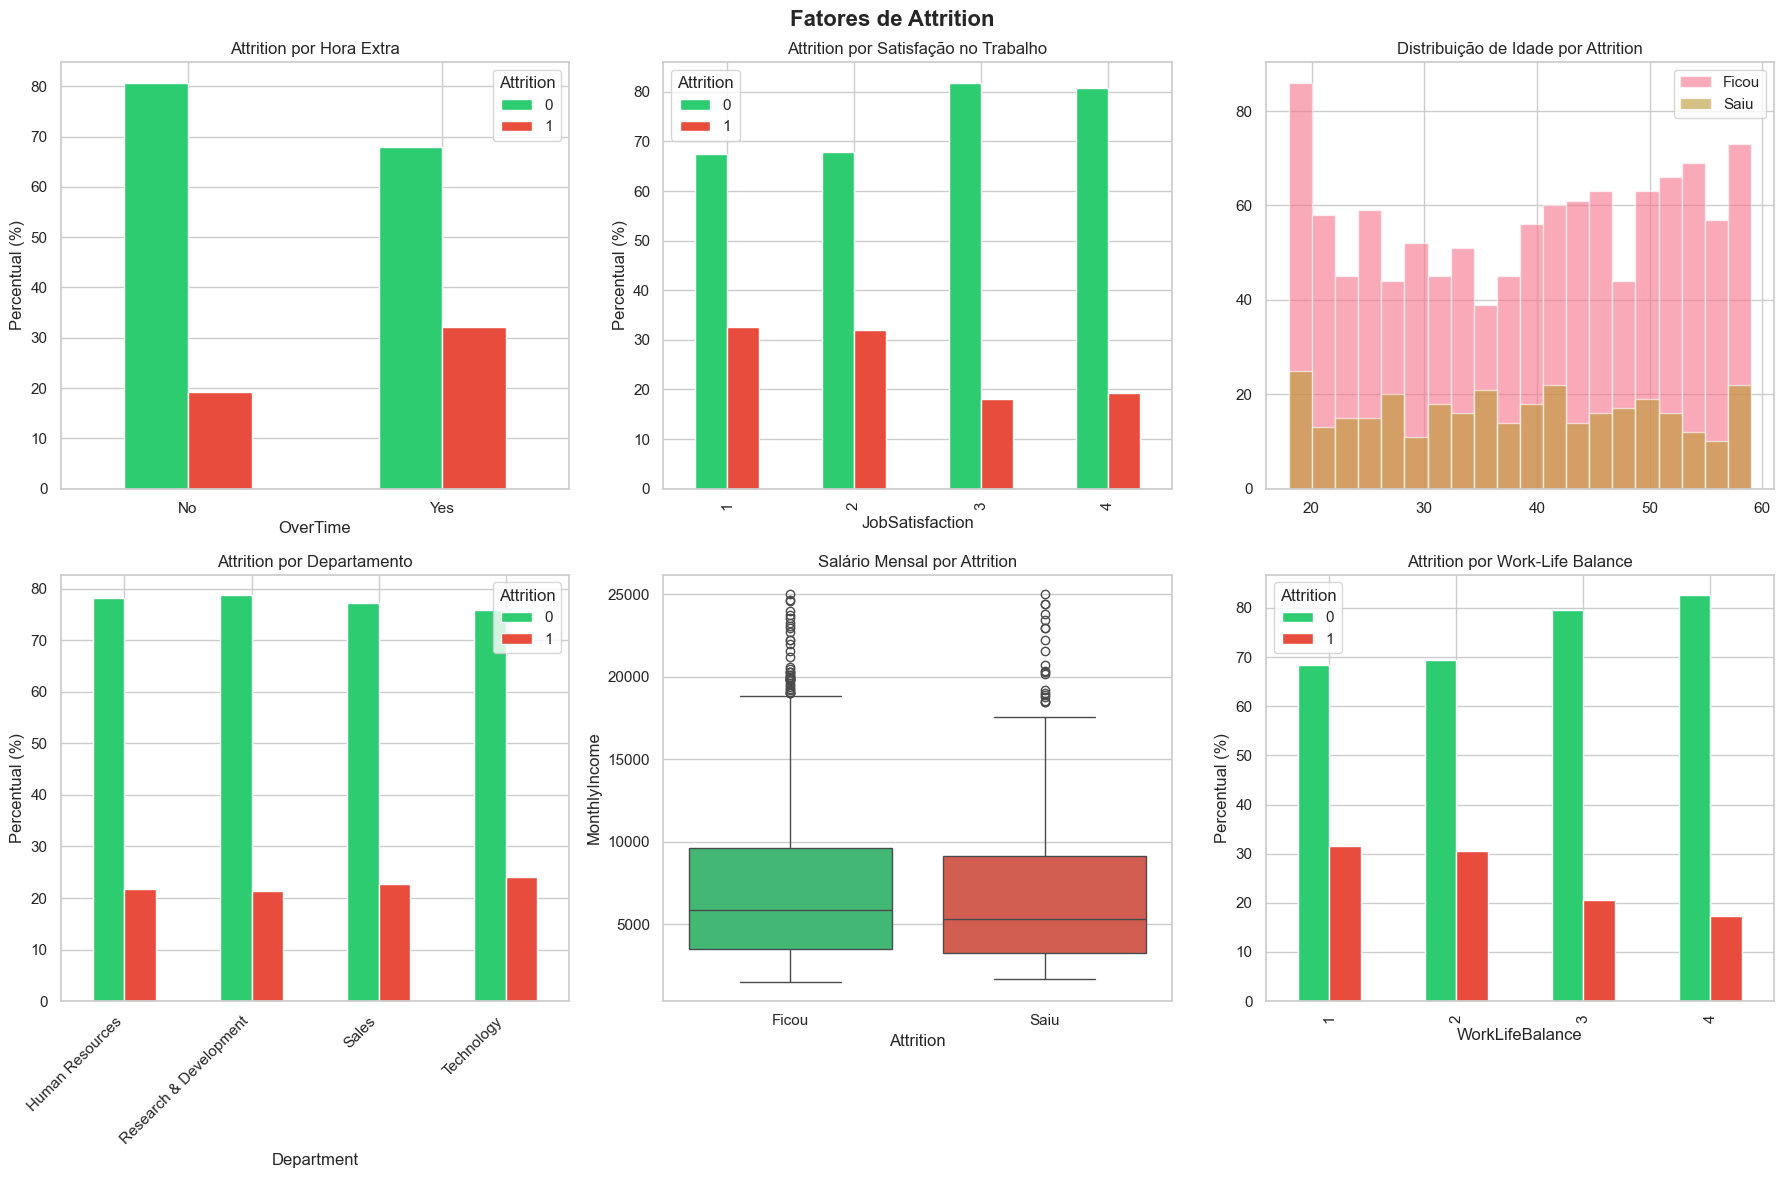

Gráfico salvo em assets/attrition_factors.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Fatores de Attrition', fontsize=16, fontweight='bold')

# 1. Attrition por OverTime
ct = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
ct.plot(kind='bar', ax=axes[0,0], color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Attrition por Hora Extra')
axes[0,0].set_ylabel('Percentual (%)')
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)

# 2. Attrition por JobSatisfaction
ct2 = pd.crosstab(df['JobSatisfaction'], df['Attrition'], normalize='index') * 100
ct2.plot(kind='bar', ax=axes[0,1], color=['#2ecc71', '#e74c3c'])
axes[0,1].set_title('Attrition por Satisfação no Trabalho')
axes[0,1].set_ylabel('Percentual (%)')

# 3. Distribuição de Idade por Attrition
for val in [0, 1]:
    subset = df[df['Attrition'] == val]
    label = 'Ficou' if val == 0 else 'Saiu'
    axes[0,2].hist(subset['Age'], bins=20, alpha=0.6, label=label)
axes[0,2].set_title('Distribuição de Idade por Attrition')
axes[0,2].legend()

# 4. Attrition por Departamento
ct3 = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
ct3.plot(kind='bar', ax=axes[1,0], color=['#2ecc71', '#e74c3c'])
axes[1,0].set_title('Attrition por Departamento')
axes[1,0].set_ylabel('Percentual (%)')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45, ha='right')

# 5. Income vs Attrition
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[1,1], palette=['#2ecc71', '#e74c3c'])
axes[1,1].set_title('Salário Mensal por Attrition')
axes[1,1].set_xticklabels(['Ficou', 'Saiu'])

# 6. WorkLifeBalance vs Attrition
ct4 = pd.crosstab(df['WorkLifeBalance'], df['Attrition'], normalize='index') * 100
ct4.plot(kind='bar', ax=axes[1,2], color=['#2ecc71', '#e74c3c'])
axes[1,2].set_title('Attrition por Work-Life Balance')
axes[1,2].set_ylabel('Percentual (%)')

plt.tight_layout()
plt.savefig('../assets/attrition_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em assets/attrition_factors.png")

## 3. Análise de Correlações e Matriz de Correlação

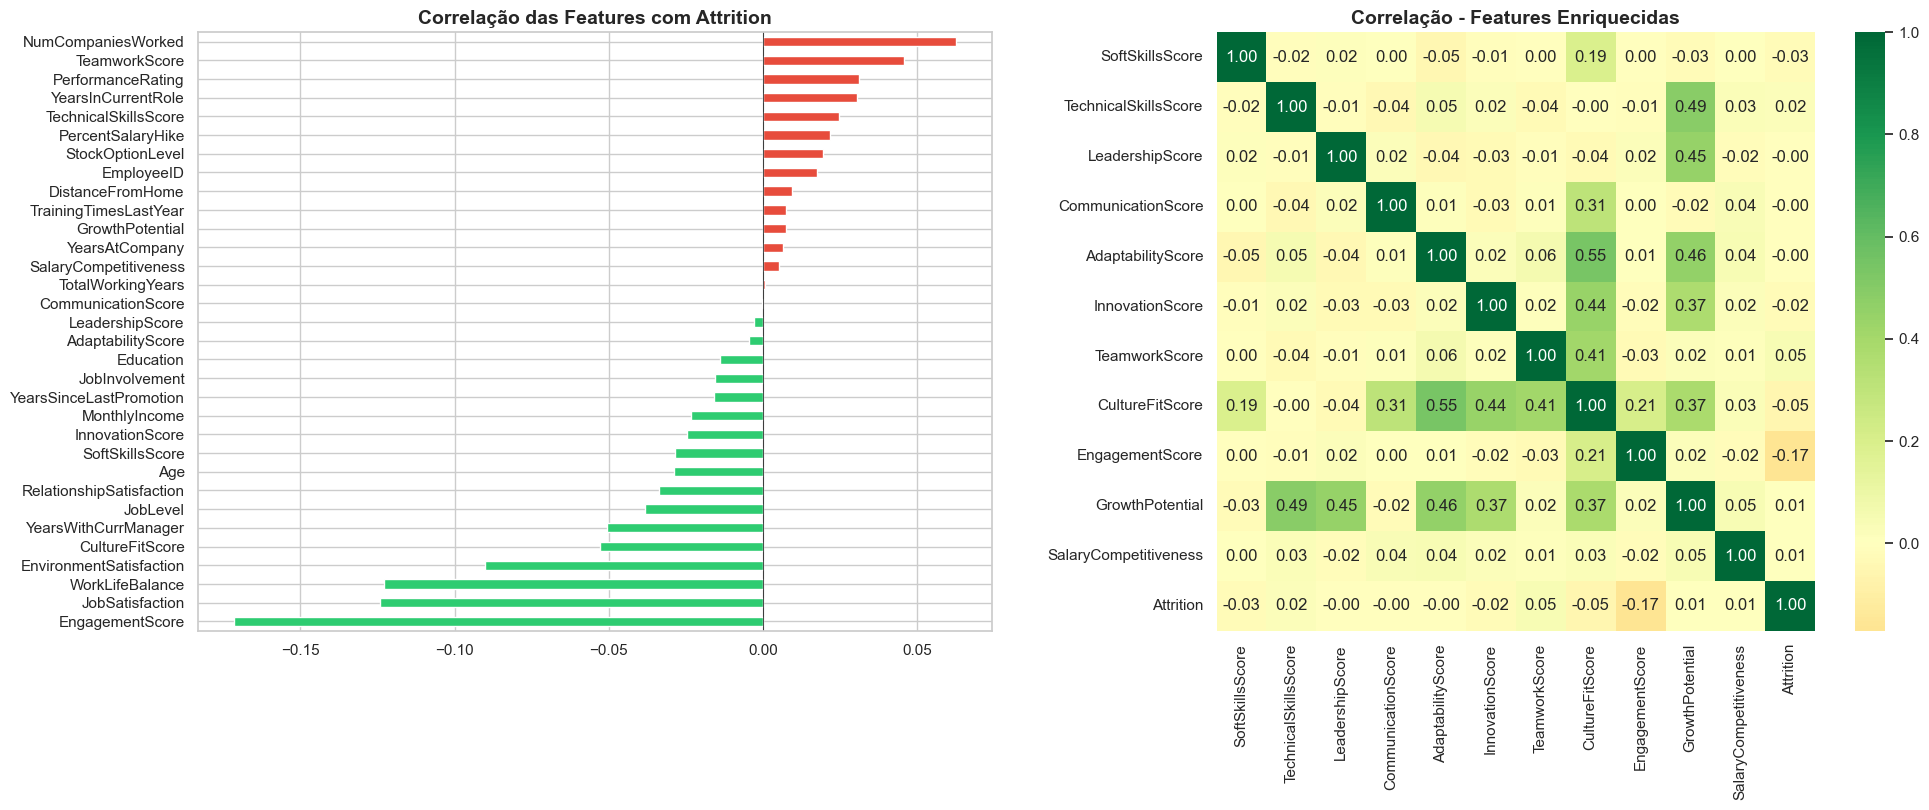

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Correlações com Attrition
attrition_corr = corr_matrix['Attrition'].drop('Attrition').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Top correlações com Attrition
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in attrition_corr]
attrition_corr.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Correlação das Features com Attrition', fontsize=14, fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Heatmap das features enriquecidas
enriched_cols = ['SoftSkillsScore', 'TechnicalSkillsScore', 'LeadershipScore',
                 'CommunicationScore', 'AdaptabilityScore', 'InnovationScore',
                 'TeamworkScore', 'CultureFitScore', 'EngagementScore',
                 'GrowthPotential', 'SalaryCompetitiveness', 'Attrition']
sns.heatmap(df[enriched_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1], square=True)
axes[1].set_title('Correlação - Features Enriquecidas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Análise dos Scores Enriquecidos por Departamento e Cargo

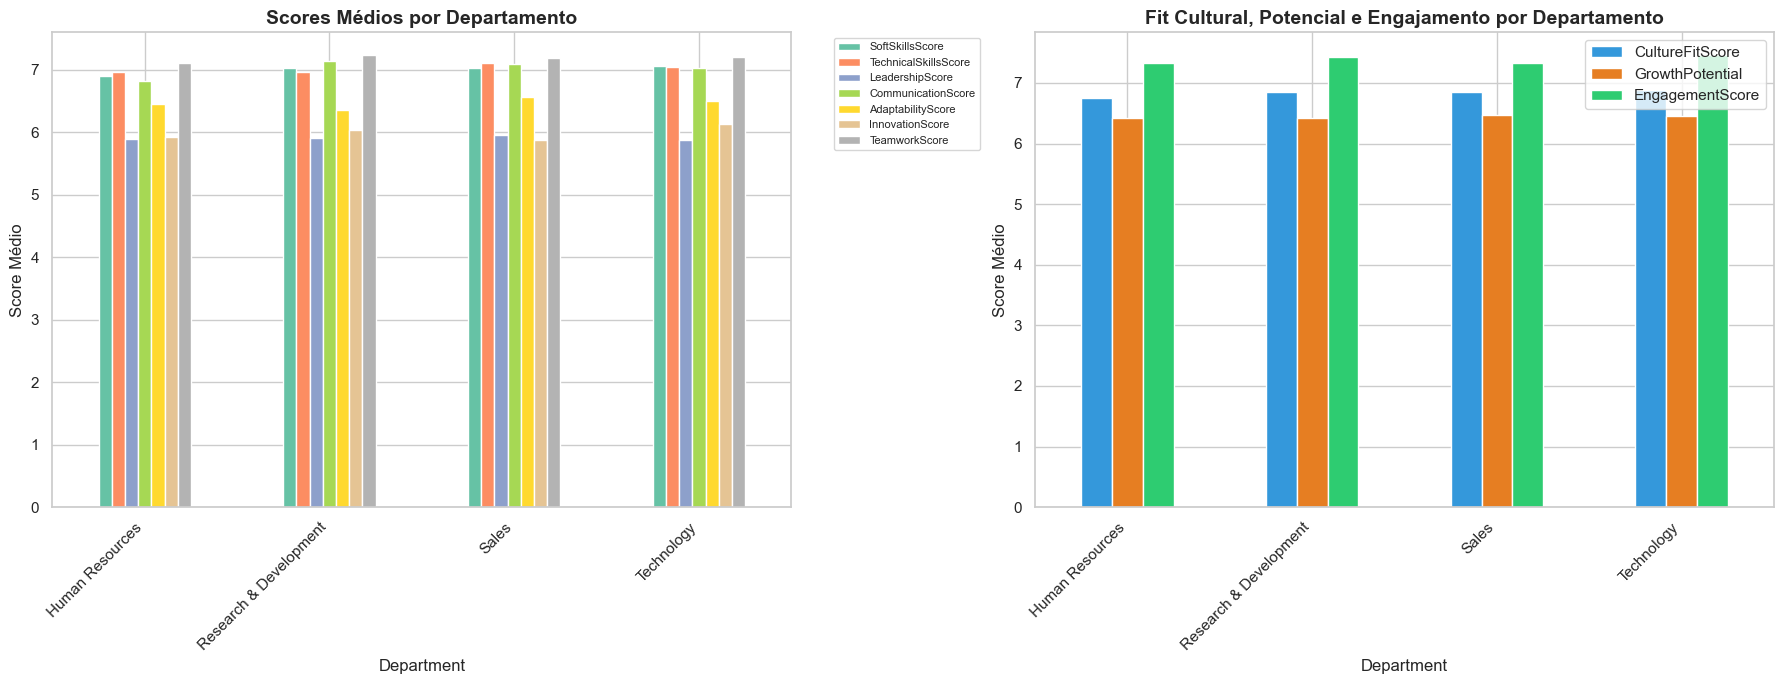

In [6]:
score_cols = ['SoftSkillsScore', 'TechnicalSkillsScore', 'LeadershipScore',
              'CommunicationScore', 'AdaptabilityScore', 'InnovationScore', 'TeamworkScore']

# Scores médios por departamento
dept_scores = df.groupby('Department')[score_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Radar-like bar chart por departamento
dept_scores.plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Scores Médios por Departamento', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score Médio')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Culture Fit e Growth Potential por Departamento
dept_meta = df.groupby('Department')[['CultureFitScore', 'GrowthPotential', 'EngagementScore']].mean()
dept_meta.plot(kind='bar', ax=axes[1], color=['#3498db', '#e67e22', '#2ecc71'])
axes[1].set_title('Fit Cultural, Potencial e Engajamento por Departamento', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score Médio')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../assets/department_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análise de Distribuições e Outliers

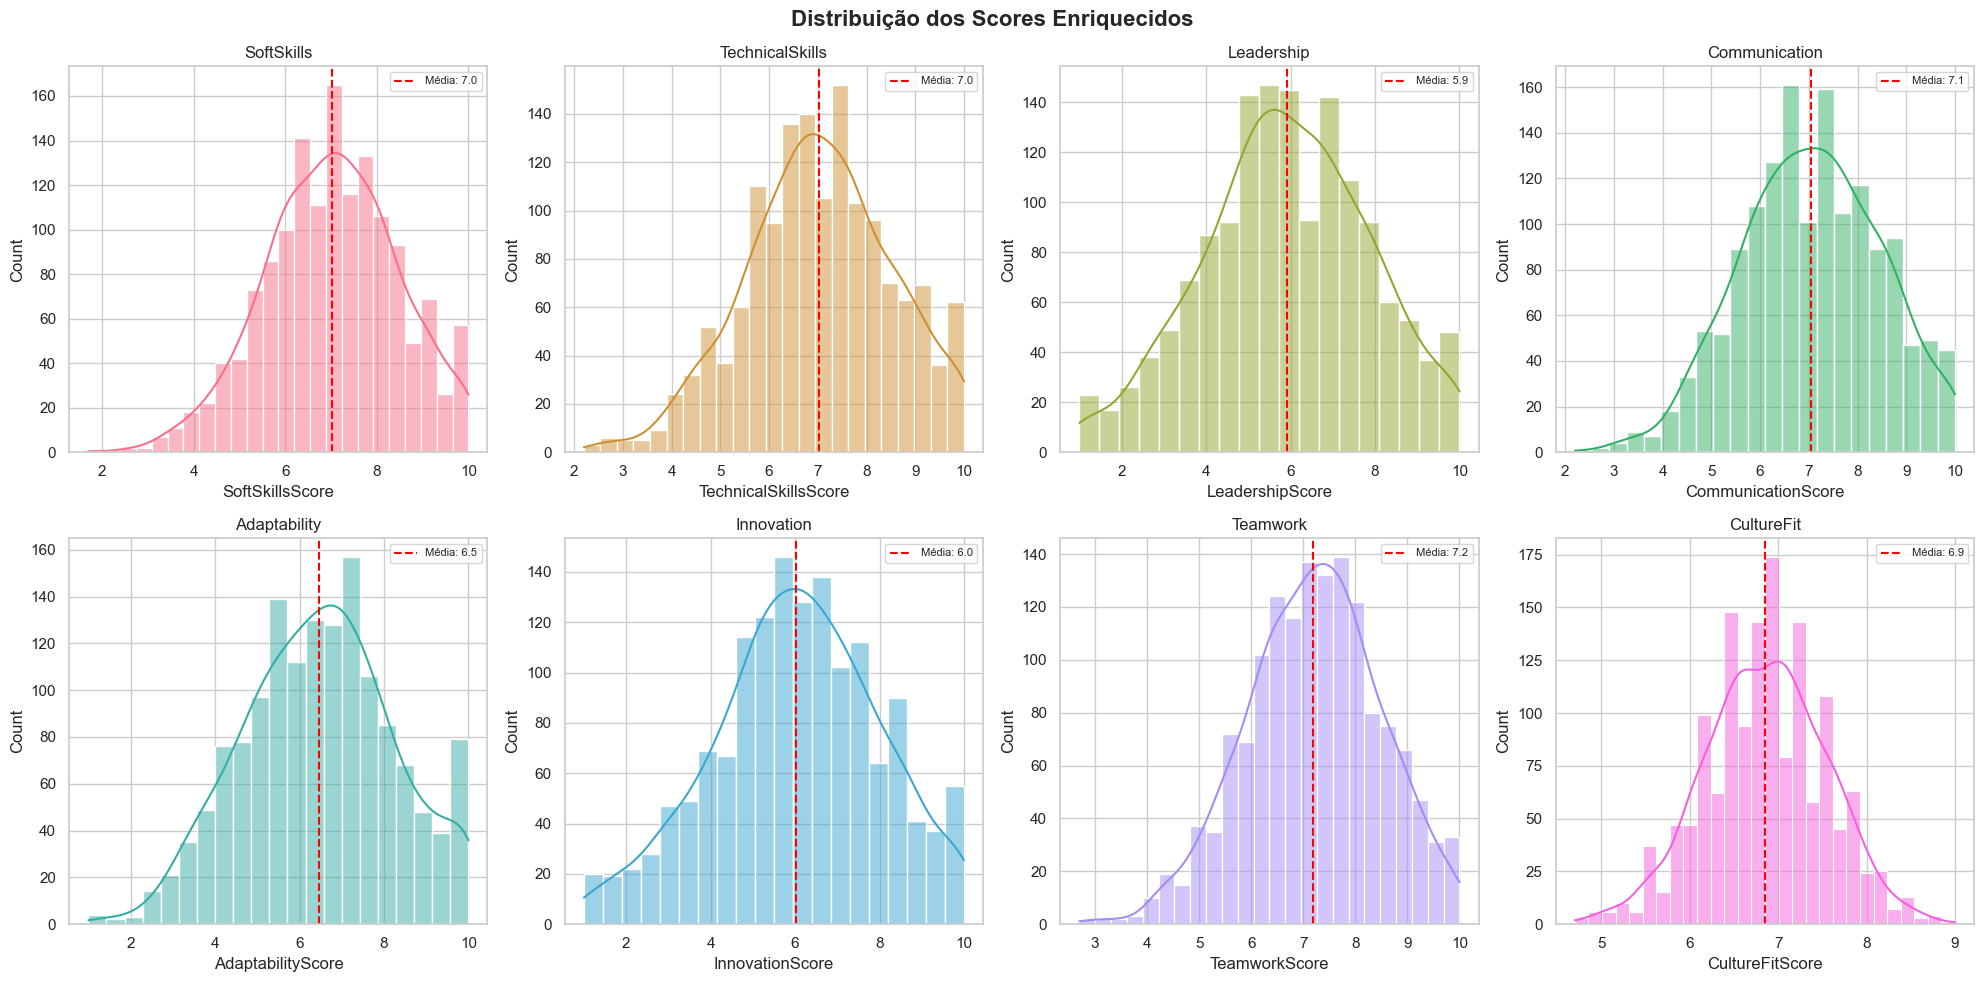

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Distribuição dos Scores Enriquecidos', fontsize=16, fontweight='bold')

for idx, col in enumerate(score_cols + ['CultureFitScore']):
    row, c = divmod(idx, 4)
    ax = axes[row, c]
    sns.histplot(df[col], kde=True, ax=ax, color=sns.color_palette('husl', 8)[idx])
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Média: {df[col].mean():.1f}')
    ax.set_title(col.replace('Score', ''))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../assets/score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Preparação dos Dados para Machine Learning

In [8]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, accuracy_score, f1_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib

# Encoding das variáveis categóricas
df_ml = df.copy()
le_dict = {}
cat_cols = df_ml.select_dtypes(include=['object']).columns

for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    le_dict[col] = le

print(f"Colunas categóricas encodadas: {list(cat_cols)}")
print(f"Shape após encoding: {df_ml.shape}")
df_ml.head()

Colunas categóricas encodadas: ['Gender', 'MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel', 'OverTime']
Shape após encoding: (1470, 40)


,EmployeeID,Age,Gender,MaritalStatus,Education,EducationField,Department,JobRole,JobLevel,MonthlyIncome,...,TechnicalSkillsScore,LeadershipScore,CommunicationScore,AdaptabilityScore,InnovationScore,TeamworkScore,CultureFitScore,EngagementScore,GrowthPotential,SalaryCompetitiveness
0,1,56,1,0,4,0,3,8,3,10505,...,4.5,6.3,7.7,6.9,1.8,8.0,5.7,7.1,5.5,105.0
1,2,46,0,2,4,4,3,8,1,2335,...,5.1,6.2,5.6,3.9,5.2,7.7,6.1,7.8,6.1,77.8
2,3,32,0,0,2,3,1,5,1,1965,...,8.7,4.7,4.6,8.9,8.3,7.8,6.5,7.1,7.5,65.5
3,4,25,1,0,4,3,2,6,1,3318,...,9.1,7.1,8.1,5.8,7.4,5.1,6.8,7.9,7.7,110.6
4,5,38,0,2,2,2,3,13,2,5451,...,5.4,8.5,6.8,4.5,5.2,8.1,6.8,5.6,5.7,90.8


## 7. Modelo de Classificação - Previsão de Attrition
Treinamento de múltiplos modelos para prever se um funcionário vai sair da empresa.

In [9]:
# Features e target para Attrition
feature_cols = [c for c in df_ml.columns if c not in ['EmployeeID', 'Attrition']]
X = df_ml[feature_cols]
y = df_ml['Attrition']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE para balancear classes
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print(f"Treino original: {y_train.value_counts().to_dict()}")
print(f"Treino após SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"Teste: {y_test.value_counts().to_dict()}")

Treino original: {0: 909, 1: 267}
Treino após SMOTE: {0: 909, 1: 909}
Teste: {0: 227, 1: 67}


In [10]:
# Treinamento de múltiplos modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, random_state=42,
                             eval_metric='logloss', verbosity=0),
}

results = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train_sm)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_sm, y_train_sm)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'accuracy': acc, 'f1_score': f1, 'auc_roc': auc,
        'y_pred': y_pred, 'y_proba': y_proba, 'model': model
    }
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Ficou', 'Saiu']))


  Logistic Regression
  Accuracy: 0.7517 | F1-Score: 0.0519 | AUC-ROC: 0.6711
              precision    recall  f1-score   support

       Ficou       0.77      0.96      0.86       227
        Saiu       0.20      0.03      0.05        67

    accuracy                           0.75       294
   macro avg       0.49      0.50      0.45       294
weighted avg       0.64      0.75      0.67       294




  Random Forest
  Accuracy: 0.6667 | F1-Score: 0.1695 | AUC-ROC: 0.5996
              precision    recall  f1-score   support

       Ficou       0.77      0.82      0.79       227
        Saiu       0.20      0.15      0.17        67

    accuracy                           0.67       294
   macro avg       0.48      0.48      0.48       294
weighted avg       0.64      0.67      0.65       294




  Gradient Boosting
  Accuracy: 0.6803 | F1-Score: 0.2034 | AUC-ROC: 0.5634
              precision    recall  f1-score   support

       Ficou       0.77      0.83      0.80       227
        Saiu       0.24      0.18      0.20        67

    accuracy                           0.68       294
   macro avg       0.50      0.50      0.50       294
weighted avg       0.65      0.68      0.66       294




  XGBoost
  Accuracy: 0.7211 | F1-Score: 0.2407 | AUC-ROC: 0.6290
              precision    recall  f1-score   support

       Ficou       0.79      0.88      0.83       227
        Saiu       0.32      0.19      0.24        67

    accuracy                           0.72       294
   macro avg       0.55      0.54      0.53       294
weighted avg       0.68      0.72      0.70       294



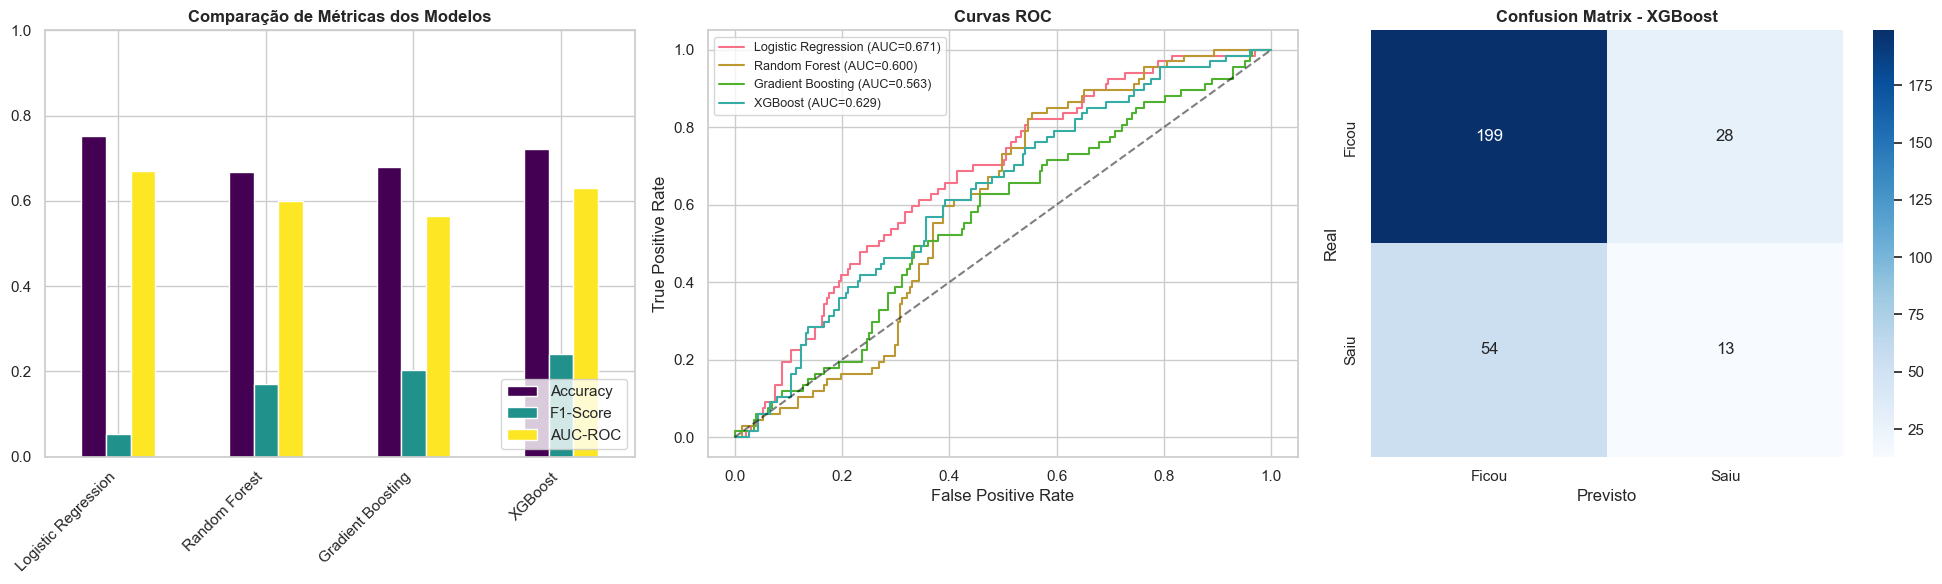


Melhor modelo: XGBoost


In [11]:
# Comparação visual dos modelos
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Métricas comparativas
metrics_df = pd.DataFrame({
    name: {'Accuracy': r['accuracy'], 'F1-Score': r['f1_score'], 'AUC-ROC': r['auc_roc']}
    for name, r in results.items()
}).T
metrics_df.plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Comparação de Métricas dos Modelos', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].legend(loc='lower right')

# 2. ROC Curves
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={r['auc_roc']:.3f})")
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[1].set_title('Curvas ROC', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

# 3. Confusion Matrix do melhor modelo
best_name = max(results, key=lambda x: results[x]['f1_score'])
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Ficou', 'Saiu'], yticklabels=['Ficou', 'Saiu'])
axes[2].set_title(f'Confusion Matrix - {best_name}', fontweight='bold')
axes[2].set_ylabel('Real')
axes[2].set_xlabel('Previsto')

plt.tight_layout()
plt.savefig('../assets/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nMelhor modelo: {best_name}")

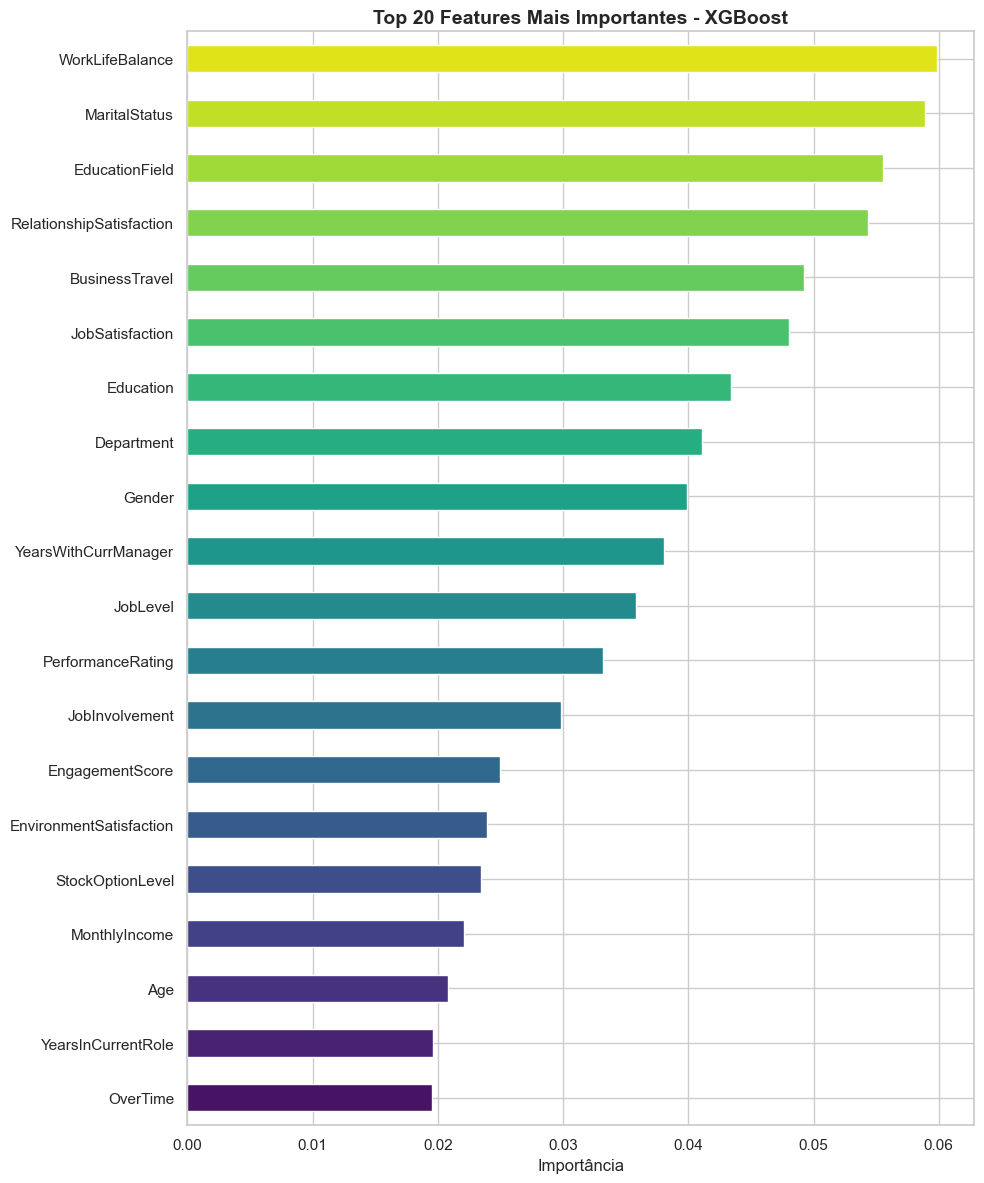

In [12]:
# Feature Importance do melhor modelo
best_model = results[best_name]['model']
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 12))
    importance.tail(20).plot(kind='barh', ax=ax, color=sns.color_palette('viridis', 20))
    ax.set_title(f'Top 20 Features Mais Importantes - {best_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importância')
    plt.tight_layout()
    plt.savefig('../assets/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Clustering com K-Means - Perfis de Funcionários
Segmentar funcionários em clusters para identificar perfis distintos.

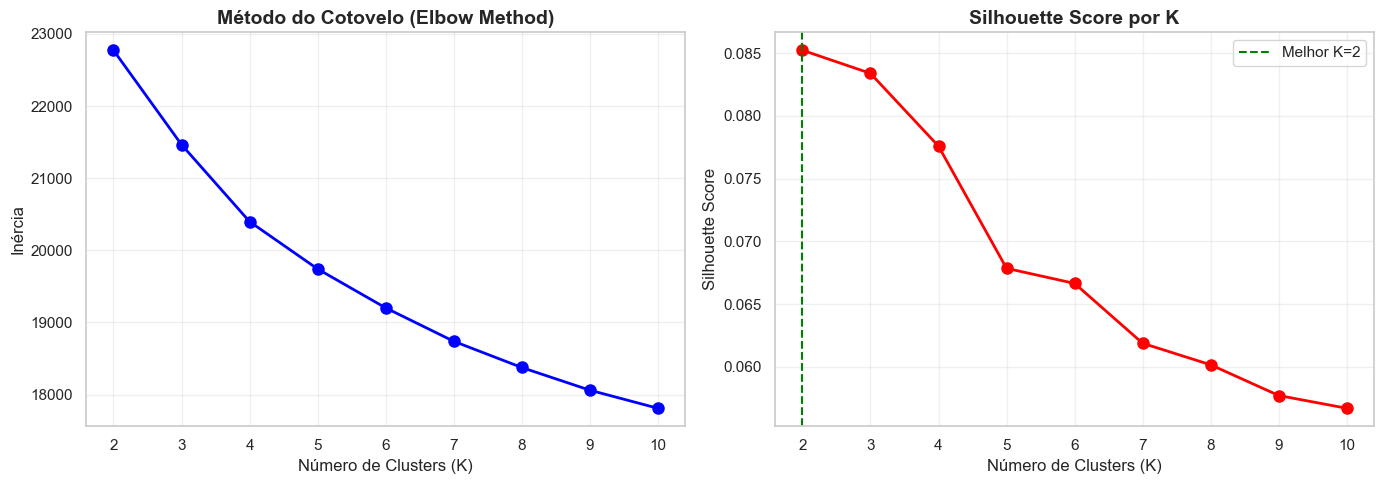

Melhor K pelo Silhouette Score: 2


In [13]:
# Features para clustering
cluster_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears',
                    'JobSatisfaction', 'WorkLifeBalance', 'PerformanceRating',
                    'SoftSkillsScore', 'TechnicalSkillsScore', 'LeadershipScore',
                    'CommunicationScore', 'AdaptabilityScore', 'InnovationScore',
                    'TeamworkScore', 'CultureFitScore', 'EngagementScore',
                    'GrowthPotential']

X_cluster = df_ml[cluster_features].copy()
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Método do Cotovelo para encontrar K ideal
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Método do Cotovelo (Elbow Method)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
from sklearn.metrics import silhouette_score
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

axes[1].plot(K_range, sil_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score por K', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

best_k = K_range[np.argmax(sil_scores)]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'Melhor K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Melhor K pelo Silhouette Score: {best_k}")

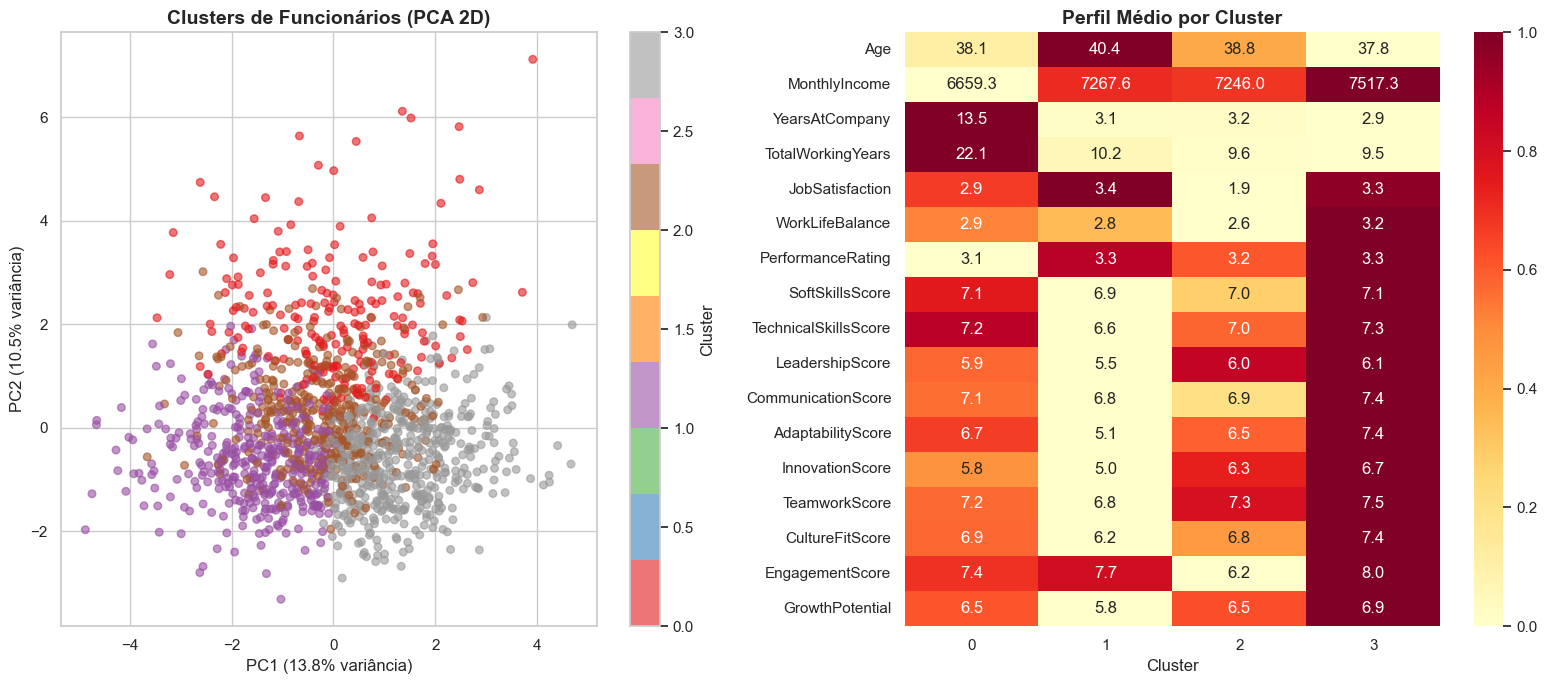


  CLUSTER 0 (205 funcionários - 14%)
  Idade média: 38 anos
  Salário médio: R$ 6,659
  Anos na empresa: 13.5
  Culture Fit: 6.9
  Engajamento: 7.4
  Potencial crescimento: 6.5
  Taxa Attrition: 24.9%

  CLUSTER 1 (404 funcionários - 27%)
  Idade média: 40 anos
  Salário médio: R$ 7,268
  Anos na empresa: 3.1
  Culture Fit: 6.2
  Engajamento: 7.7
  Potencial crescimento: 5.8
  Taxa Attrition: 19.3%

  CLUSTER 2 (348 funcionários - 24%)
  Idade média: 39 anos
  Salário médio: R$ 7,246
  Anos na empresa: 3.2
  Culture Fit: 6.8
  Engajamento: 6.2
  Potencial crescimento: 6.5
  Taxa Attrition: 33.3%

  CLUSTER 3 (513 funcionários - 35%)
  Idade média: 38 anos
  Salário médio: R$ 7,517
  Anos na empresa: 2.9
  Culture Fit: 7.4
  Engajamento: 8.0
  Potencial crescimento: 6.9
  Taxa Attrition: 17.3%


In [14]:
# Aplicar K-Means com K=4 (perfis de RH fazem sentido com 4 grupos)
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)
df_ml['Cluster'] = df['Cluster']

# PCA para visualização 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter plot PCA
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'],
                          cmap='Set1', alpha=0.6, s=30)
axes[0].set_title('Clusters de Funcionários (PCA 2D)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variância)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variância)')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Perfil médio de cada cluster
cluster_profile = df.groupby('Cluster')[cluster_features].mean()
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
sns.heatmap(cluster_profile_norm.T, annot=cluster_profile.T.round(1).values,
            fmt='', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Perfil Médio por Cluster', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster')

plt.tight_layout()
plt.savefig('../assets/clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# Descrição dos clusters
cluster_names = {0: '', 1: '', 2: '', 3: ''}
for c in range(K_FINAL):
    subset = df[df['Cluster'] == c]
    print(f"\n{'='*60}")
    print(f"  CLUSTER {c} ({len(subset)} funcionários - {len(subset)/len(df):.0%})")
    print(f"{'='*60}")
    print(f"  Idade média: {subset['Age'].mean():.0f} anos")
    print(f"  Salário médio: R$ {subset['MonthlyIncome'].mean():,.0f}")
    print(f"  Anos na empresa: {subset['YearsAtCompany'].mean():.1f}")
    print(f"  Culture Fit: {subset['CultureFitScore'].mean():.1f}")
    print(f"  Engajamento: {subset['EngagementScore'].mean():.1f}")
    print(f"  Potencial crescimento: {subset['GrowthPotential'].mean():.1f}")
    print(f"  Taxa Attrition: {subset['Attrition'].mean():.1%}")

## 9. Salvando Modelos Treinados
Exportar modelos para uso na aplicação Streamlit.

In [15]:
# Salvar o melhor modelo de classificação (para Attrition)
best_clf = results[best_name]['model']
joblib.dump(best_clf, '../models/attrition_model.joblib')
print(f"Modelo de Attrition salvo: {best_name}")

# Salvar modelo K-Means
joblib.dump(kmeans, '../models/kmeans_model.joblib')
print("Modelo K-Means salvo")

# Salvar scalers
joblib.dump(scaler, '../models/scaler_classification.joblib')
joblib.dump(scaler_cluster, '../models/scaler_cluster.joblib')
print("Scalers salvos")

# Salvar label encoders
joblib.dump(le_dict, '../models/label_encoders.joblib')
print("Label encoders salvos")

# Salvar lista de features
joblib.dump(feature_cols, '../models/feature_cols.joblib')
joblib.dump(cluster_features, '../models/cluster_features.joblib')
print("Feature lists salvas")

# Salvar PCA
joblib.dump(pca, '../models/pca_model.joblib')
print("PCA salvo")

print(f"\nTodos os artefatos salvos na pasta models/")

Modelo de Attrition salvo: XGBoost
Modelo K-Means salvo
Scalers salvos
Label encoders salvos
Feature lists salvas
PCA salvo

Todos os artefatos salvos na pasta models/


## 10. Conclusões da Análise

### Principais Insights:
1. **Attrition**: Hora extra, baixa satisfação e distância do trabalho são os maiores preditores de saída
2. **Clusters**: Identificamos 4 perfis distintos de funcionários com diferentes níveis de engajamento e risco
3. **Modelos**: Os modelos ensemble (XGBoost/Gradient Boosting) apresentam melhor performance na previsão de attrition
4. **Features enriquecidas**: Culture Fit Score e Engagement Score agregam valor preditivo significativo

### Próximos passos:
- Integrar os modelos com a interface de RH via Streamlit
- Usar NLP (GPT) para gerar perguntas de entrevista personalizadas
- Usar as respostas do candidato para alimentar os modelos e gerar previsões em tempo real